<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  20/06/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-1</strong></p>
</div>

---

Link: https://drive.google.com/file/d/13Zp2ox0xNqHBGlRwYMf4wQxJ9SIsOLTx/view?usp=sharing

In [13]:
import pandas as pd

# **LEAMOS EL DATASET FINAL**

In [6]:
df =  pd.read_csv("df_FINAL.csv")

In [8]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-26 00:35:00,0.0,189.0,31.0,69.258790,-0.020608,0.010838,3.0,-1.416667,2.0,165.4,29.083333,0.161
1,2025-01-26 00:36:00,0.0,189.0,32.0,68.826191,-0.019268,0.010848,3.0,-1.400000,2.0,165.4,29.000000,0.122
2,2025-01-26 00:37:00,0.0,197.0,32.0,68.393592,-0.017928,0.010858,3.0,-1.383333,2.0,165.4,28.916667,0.128
3,2025-01-26 00:38:00,0.0,189.0,33.0,67.960993,-0.016589,0.010867,3.0,-1.366667,2.0,165.4,28.833333,0.106
4,2025-01-26 00:39:00,0.0,196.0,32.0,67.528394,-0.015249,0.010877,3.0,-1.350000,2.0,165.4,28.750000,0.103


In [ ]:
!pip install cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 3.0 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 11.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 11.0 MB/s eta 0:00:00 MB/s eta 0:00:01


In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Diccionario con las estaciones y coordenadas
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}
# Ajustes de posición de texto (lon_offset, lat_offset)
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}

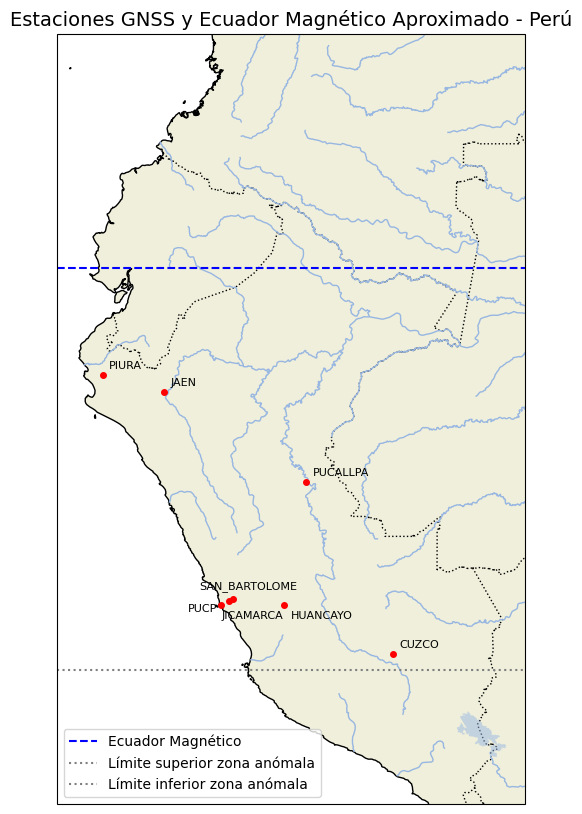

In [19]:
# Crear figura y mapa
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Características físicas
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.set_extent([-82, -68, -18, 5])  # Perú extendido al norte

# Dibujar estaciones
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, transform=ccrs.PlateCarree())
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=8, transform=ccrs.PlateCarree())

# Dibujar ecuador magnético aproximado (línea recta)
longitudes = list(range(-82, -67))  # de oeste a este
lat_ecuador_magnetico = [ -2.0 ] * len(longitudes)  # Ecuador magnético aprox. Perú ~ -2°
lat_banda_anomala_norte = [ 10.0 ] * len(longitudes)
lat_banda_anomala_sur = [ -14.0 ] * len(longitudes)

ax.plot(longitudes, lat_ecuador_magnetico, linestyle='--', color='blue', label='Ecuador Magnético', transform=ccrs.PlateCarree())
ax.plot(longitudes, lat_banda_anomala_norte, linestyle=':', color='gray', label='Límite superior zona anómala', transform=ccrs.PlateCarree())
ax.plot(longitudes, lat_banda_anomala_sur, linestyle=':', color='gray', label='Límite inferior zona anómala', transform=ccrs.PlateCarree())

# Leyenda y título
plt.legend(loc='lower left')
plt.title("Estaciones GNSS y Ecuador Magnético Aproximado - Perú", fontsize=14)
plt.grid(True)
plt.show()

In [106]:
!pip install wmm2020

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.4 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.1 MB/s eta 0:00:00
  Created wheel for wmm2020: filename=wmm2020-1.1.1-py3-none-any.whl size=3183606 sha256=56fe53da719e1046007c33415764f74bb3392f111975429d2ef2524f6c962fe5
  Stored in directory: /home/soporte/.cache/pip/wheels/3f/84/cd/a6077b1e81ff6670606f219882dcfd62ed1358a7327fe5483c
Successfully built wmm2020
Note: you may need to restart the kernel to use updated packages.


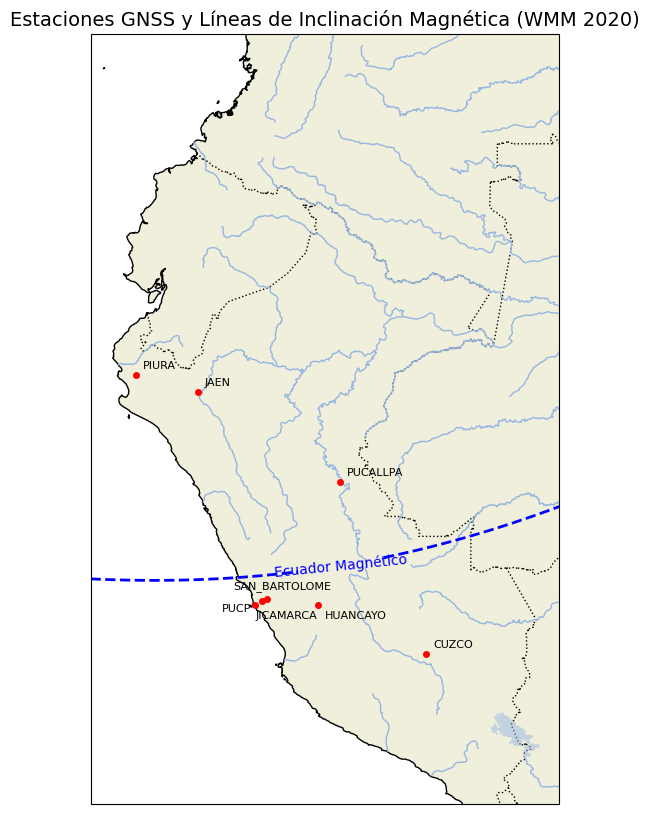

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from wmm2020 import wmm

# 1. Definir grilla sobre el Perú
lons = np.linspace(-82, -68, 200)
lats = np.linspace(-18, 5, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# 2. Calcular inclinación magnética (dip angle) en cada punto (altura 100 km)
inclination = np.zeros_like(lat_grid)
for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']  # <- aquí está la corrección

# 3. Estaciones GNSS
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}

# Desplazamientos de texto para evitar sobreposición
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}
# 4. Graficar
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-82, -68, -18, 5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.5)

# 1. Dibujar línea de inclinación = 0° (Ecuador Magnético)
cs0 = ax.contour(lon_grid, lat_grid, inclination, levels=[0], colors='blue', linewidths=2, linestyles='--')

# Verificamos si hay segmentos en la línea para evitar el error
if len(cs0.allsegs[0]) > 0:
    # Elegimos el primer segmento del contorno
    seg = cs0.allsegs[0][0]
    # Tomamos un punto medio (ajustar el índice para mover la etiqueta)
    label_point = seg[len(seg)//2]
    # Desplazamos el texto ligeramente hacia arriba en latitud
    manual_loc = [(label_point[0], label_point[1] + 1.5)]
    ax.clabel(cs0, fmt=lambda _: "Ecuador Magnético", inline=True, fontsize=10, manual=manual_loc)


# Dibujar estaciones
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, transform=ccrs.PlateCarree())
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=8, transform=ccrs.PlateCarree())

# Título
plt.title("Estaciones GNSS y Líneas de Inclinación Magnética (WMM 2020)", fontsize=14)
plt.grid(True)
plt.show()

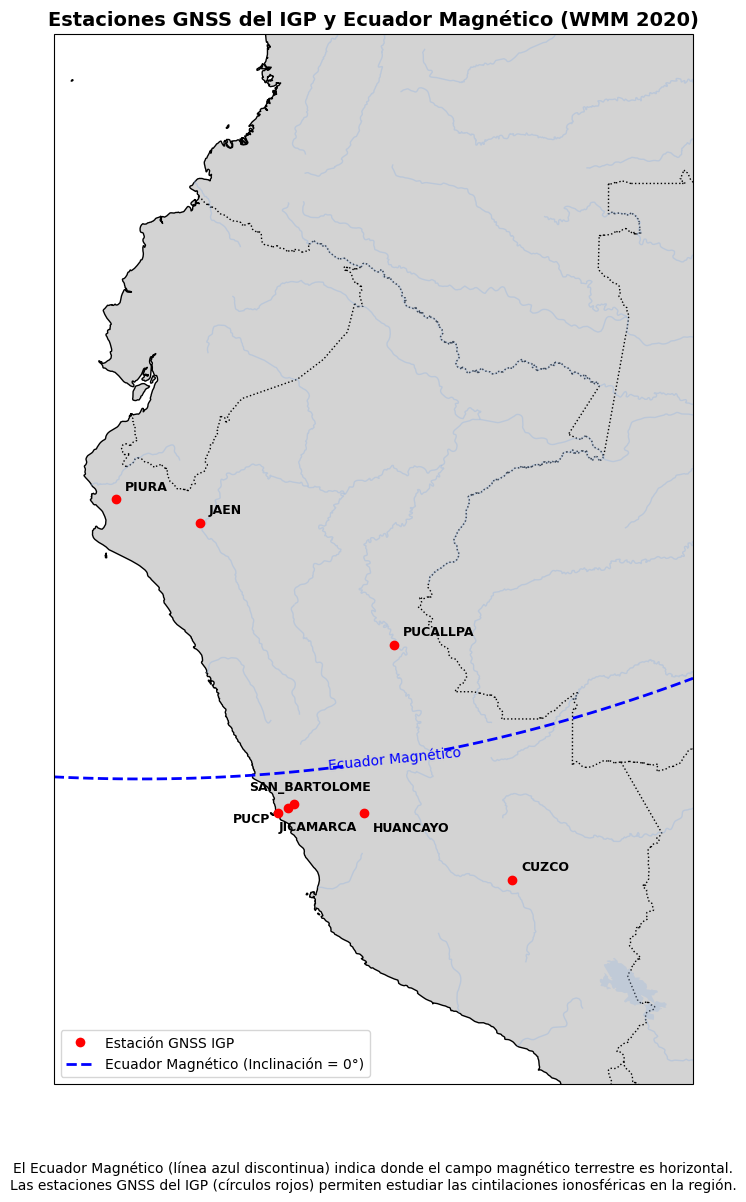

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from wmm2020 import wmm

# 1. Definir grilla sobre el Perú
lons = np.linspace(-82, -68, 200)
lats = np.linspace(-18, 5, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# 2. Calcular inclinación magnética (dip angle) en cada punto (altura 100 km)
inclination = np.zeros_like(lat_grid)
for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']

# 3. Estaciones GNSS
ubicaciones = {
    "CUZCO": (-13.5320, -71.9675),
    "JAEN": (-5.7082, -78.8024),
    "JICAMARCA": (-11.9500, -76.8700),
    "PIURA": (-5.1945, -80.6328),
    "HUANCAYO": (-12.0650, -75.2049),
    "SAN_BARTOLOME": (-11.8714, -76.7295),
    "PUCP": (-12.0682, -77.0803),
    "PUCALLPA": (-8.3791, -74.5539)
}
desplazamientos = {
    "CUZCO": (0.2, 0.2),
    "JAEN": (0.2, 0.2),
    "JICAMARCA": (-0.2, -0.5),
    "PIURA": (0.2, 0.2),
    "HUANCAYO": (0.2, -0.4),
    "SAN_BARTOLOME": (-1.0, 0.3),
    "PUCP": (-1.0, -0.2),
    "PUCALLPA": (0.2, 0.2)
}

# 4. Graficar
fig = plt.figure(figsize=(12, 12), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())

# Agregar mapa base
ax.set_extent([-82, -68, -18, 5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS, alpha=0.4)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# Dibujar línea de inclinación = 0° (Ecuador Magnético)
cs0 = ax.contour(lon_grid, lat_grid, inclination, levels=[0], colors='blue', linewidths=2, linestyles='--')

if len(cs0.allsegs[0]) > 0:
    seg = cs0.allsegs[0][0]
    label_point = seg[len(seg)//2]
    manual_loc = [(label_point[0], label_point[1] + 1.5)]
    ax.clabel(cs0, fmt=lambda _: "Ecuador Magnético", inline=True, fontsize=10, manual=manual_loc)

# Dibujar estaciones GNSS
for nombre, (lat, lon) in ubicaciones.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree(), label='_nolegend_')
    dx, dy = desplazamientos[nombre]
    ax.text(lon + dx, lat + dy, nombre, fontsize=9, weight='bold', transform=ccrs.PlateCarree())

# Añadir leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Estación GNSS IGP',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Ecuador Magnético (Inclinación = 0°)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# Título y anotación descriptiva
plt.title("Estaciones GNSS del IGP y Ecuador Magnético (WMM 2020)", fontsize=14, weight='bold')
plt.annotate(
    "El Ecuador Magnético (línea azul discontinua) indica donde el campo magnético terrestre es horizontal.\n"
    "Las estaciones GNSS del IGP (círculos rojos) permiten estudiar las cintilaciones ionosféricas en la región.",
    xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=10
)

plt.tight_layout()
plt.grid(True)
plt.show()

# **Correcion y generacion de figuras tesis 25/02/2026**

# **FIGURA 1**

 **FIGURA 1:** Distribución espacial de las estaciones GNSS activas de la red LISN–IGP. Las estaciones resaltadas en rojo corresponden a aquellas utilizadas en la implementación de los modelos de predicción del parámetro S4. La línea azul discontinua representa el Ecuador Magnético (inclinación = 0°) calculado mediante el modelo WMM 2020.

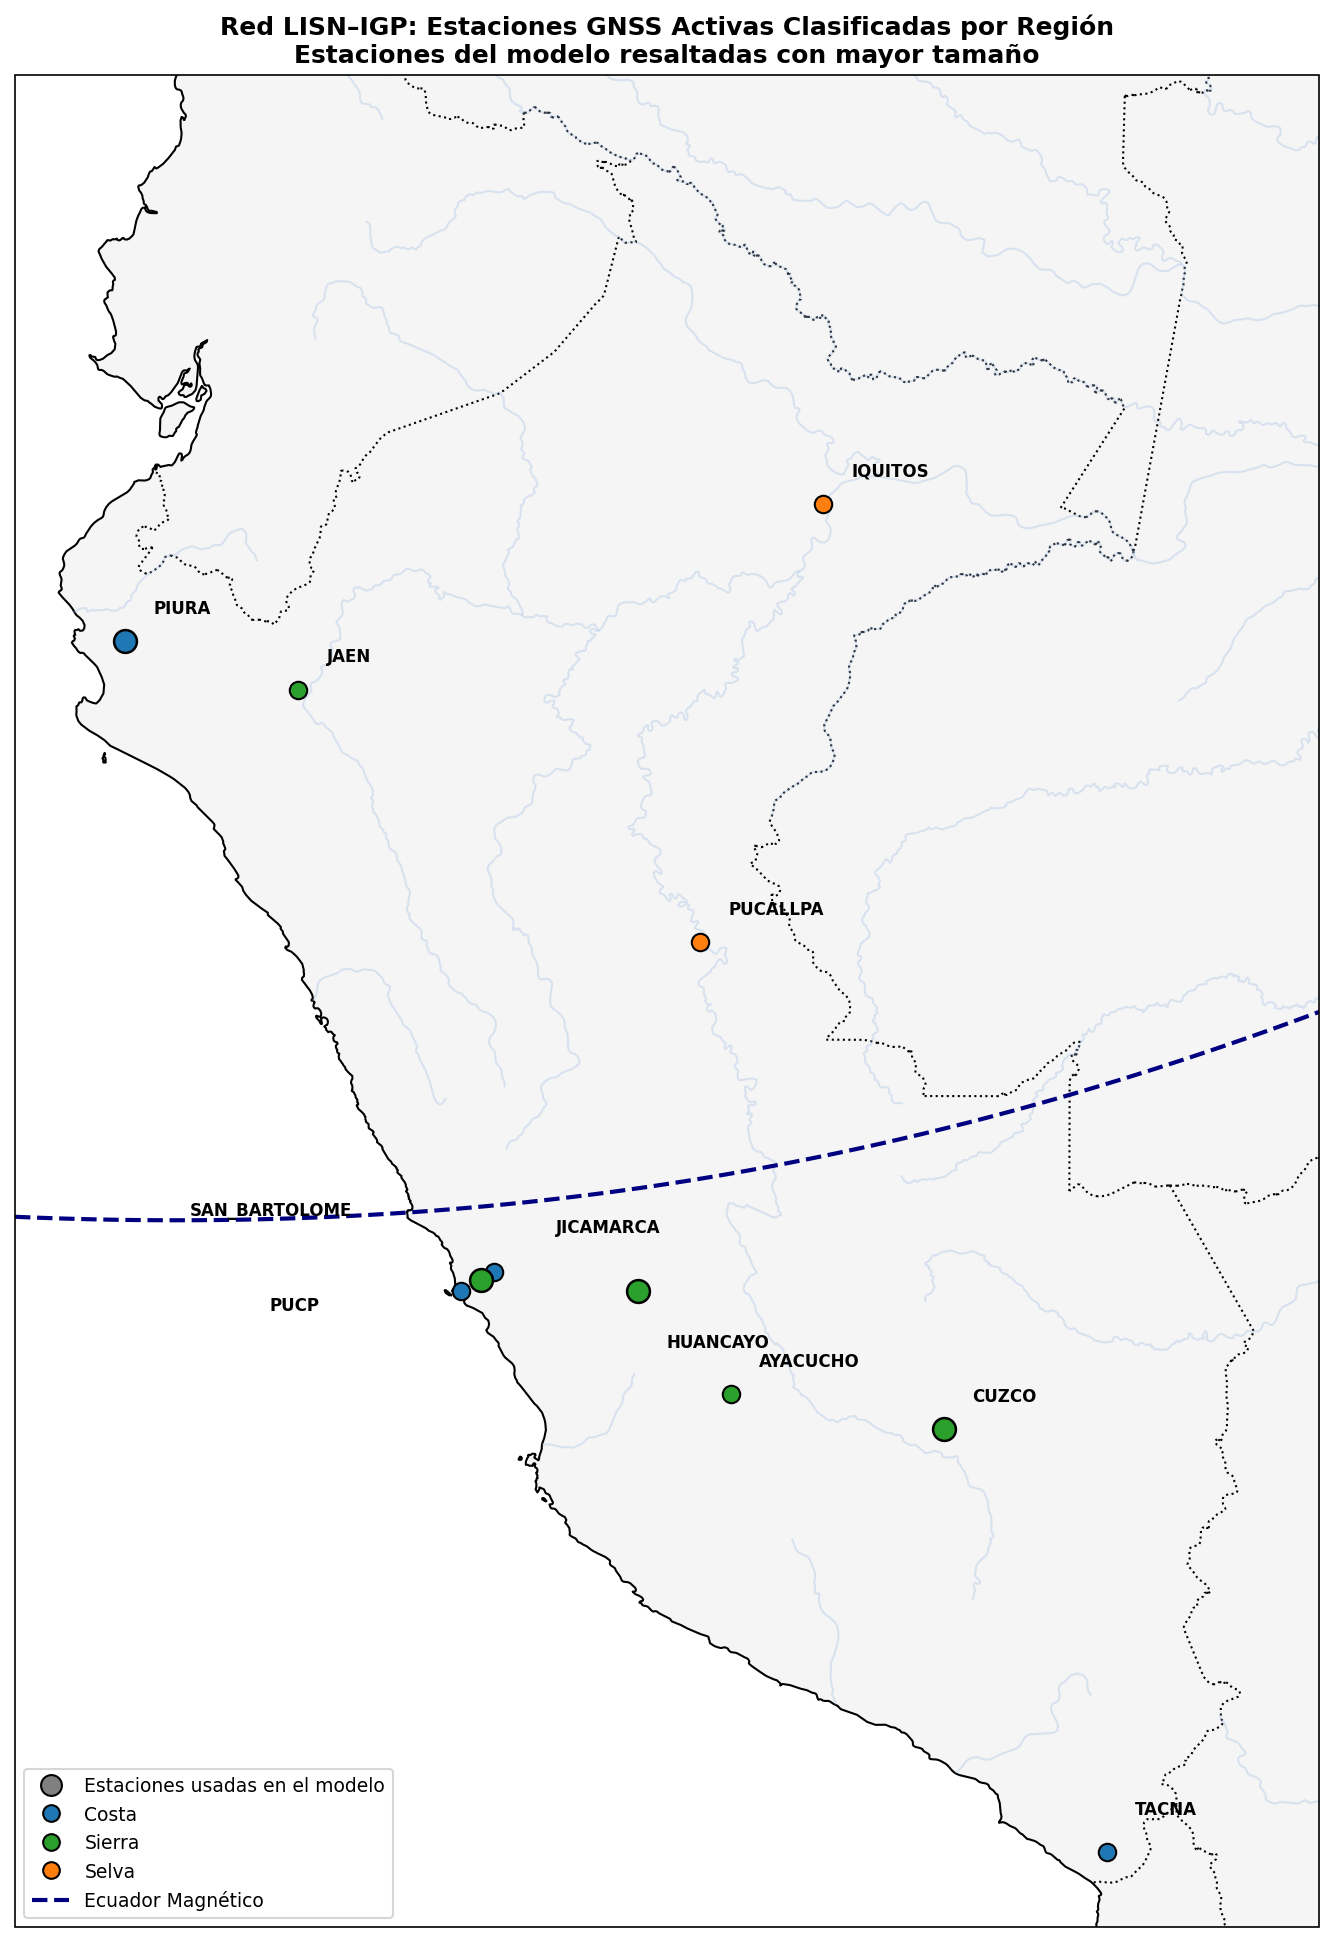

In [43]:
# ============================================================
# MAPA DEFINITIVO - LISN IGP + MODELO S4
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from wmm2020 import wmm
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Grilla ajustada solo al Perú continental
# ------------------------------------------------------------
lons = np.linspace(-81.8, -68.0, 200)
lats = np.linspace(-18.8, 0.8, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# ------------------------------------------------------------
# 2. Calcular inclinación magnética
# ------------------------------------------------------------
inclination = np.zeros_like(lat_grid)

for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']

# ------------------------------------------------------------
# 3. Estaciones con clasificación regional
# ------------------------------------------------------------
estaciones = {
    # COSTA
    "PIURA": (-5.1945, -80.6328, "Costa"),
    "PUCP": (-12.0682, -77.0803, "Costa"),
    "SAN_BARTOLOME": (-11.8714, -76.7295, "Costa"),
    "TACNA": (-18.0066, -70.2463, "Costa"),
    "JICAMARCA": (-11.9500, -76.8700, "Sierra"),


    # SIERRA
    "JAEN": (-5.7082, -78.8024, "Sierra"),
    "HUANCAYO": (-12.0650, -75.2049, "Sierra"),
    "CUZCO": (-13.5320, -71.9675, "Sierra"),
    "AYACUCHO": (-13.1631, -74.2236, "Sierra"),

    # SELVA
    "PUCALLPA": (-8.3791, -74.5539, "Selva"),
    "IQUITOS": (-3.7437, -73.2516, "Selva")
}

estaciones_modelo = ["PIURA", "JICAMARCA", "HUANCAYO", "CUZCO"]

# Colores por región
colores_region = {
    "Costa": "#1f77b4",
    "Sierra": "#2ca02c",
    "Selva": "#ff7f0e"
}

# ------------------------------------------------------------
# 4. Figura
# ------------------------------------------------------------
fig = plt.figure(figsize=(9, 13), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-81.8, -68.0, -18.8, 0.8])

ax.add_feature(cfeature.LAND, facecolor='whitesmoke')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.RIVERS, alpha=0.3)

# ------------------------------------------------------------
# 5. Ecuador Magnético
# ------------------------------------------------------------
ax.contour(lon_grid, lat_grid, inclination,
           levels=[0],
           colors='navy',
           linewidths=2,
           linestyles='--')

# ------------------------------------------------------------
# 6. Dibujar estaciones (con separación optimizada)
# ------------------------------------------------------------
for nombre, (lat, lon, region) in estaciones.items():

    color = colores_region[region]

    if nombre in estaciones_modelo:
        ax.scatter(lon, lat,
                   s=120,
                   color=color,
                   edgecolor='black',
                   linewidth=1.2,
                   zorder=5)
    else:
        ax.scatter(lon, lat,
                   s=70,
                   color=color,
                   edgecolor='black',
                   zorder=4)

    # ---------------------------
    # Desplazamientos específicos
    # ---------------------------
    dx = 0.3
    dy = 0.3
    ha = 'left'

    # ZONA LIMA – SEPARACIÓN ESTRATÉGICA
    if nombre == "PUCP":
        dx = -1.5
        dy = -0.2
        ha = 'right'

    if nombre == "SAN_BARTOLOME":
        dx = -1.5
        dy = 0.6
        ha = 'right'

    if nombre == "JICAMARCA":
        dx = 0.8
        dy = 0.5
        ha = 'left'

    # Ajustes adicionales suaves
    if nombre == "HUANCAYO":
        dy = -0.6

    if nombre == "TACNA":
        dy = 0.4

    ax.text(lon + dx, lat + dy,
            nombre,
            fontsize=8,
            weight='bold',
            ha=ha)

# ------------------------------------------------------------
# 7. Leyenda
# ------------------------------------------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Estaciones usadas en el modelo',
           markerfacecolor='gray',
           markeredgecolor='black',
           markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='Costa',
           markerfacecolor=colores_region["Costa"],
           markeredgecolor='black',
           markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='Sierra',
           markerfacecolor=colores_region["Sierra"],
           markeredgecolor='black',
           markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='Selva',
           markerfacecolor=colores_region["Selva"],
           markeredgecolor='black',
           markersize=8),

    Line2D([0], [0], color='navy',
           lw=2,
           linestyle='--',
           label='Ecuador Magnético')
]

ax.legend(handles=legend_elements,
          loc='lower left',
          fontsize=9)

plt.title("Red LISN–IGP: Estaciones GNSS Activas Clasificadas por Región\n"
          "Estaciones del modelo resaltadas con mayor tamaño",
          fontsize=12,
          weight='bold')

plt.tight_layout()
plt.savefig("Mapa_LISN_Modelo_S4_Peru_Final.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

✓ Límites departamentales cargados


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/Mapa_LISN_IGP_Mejorado.png'

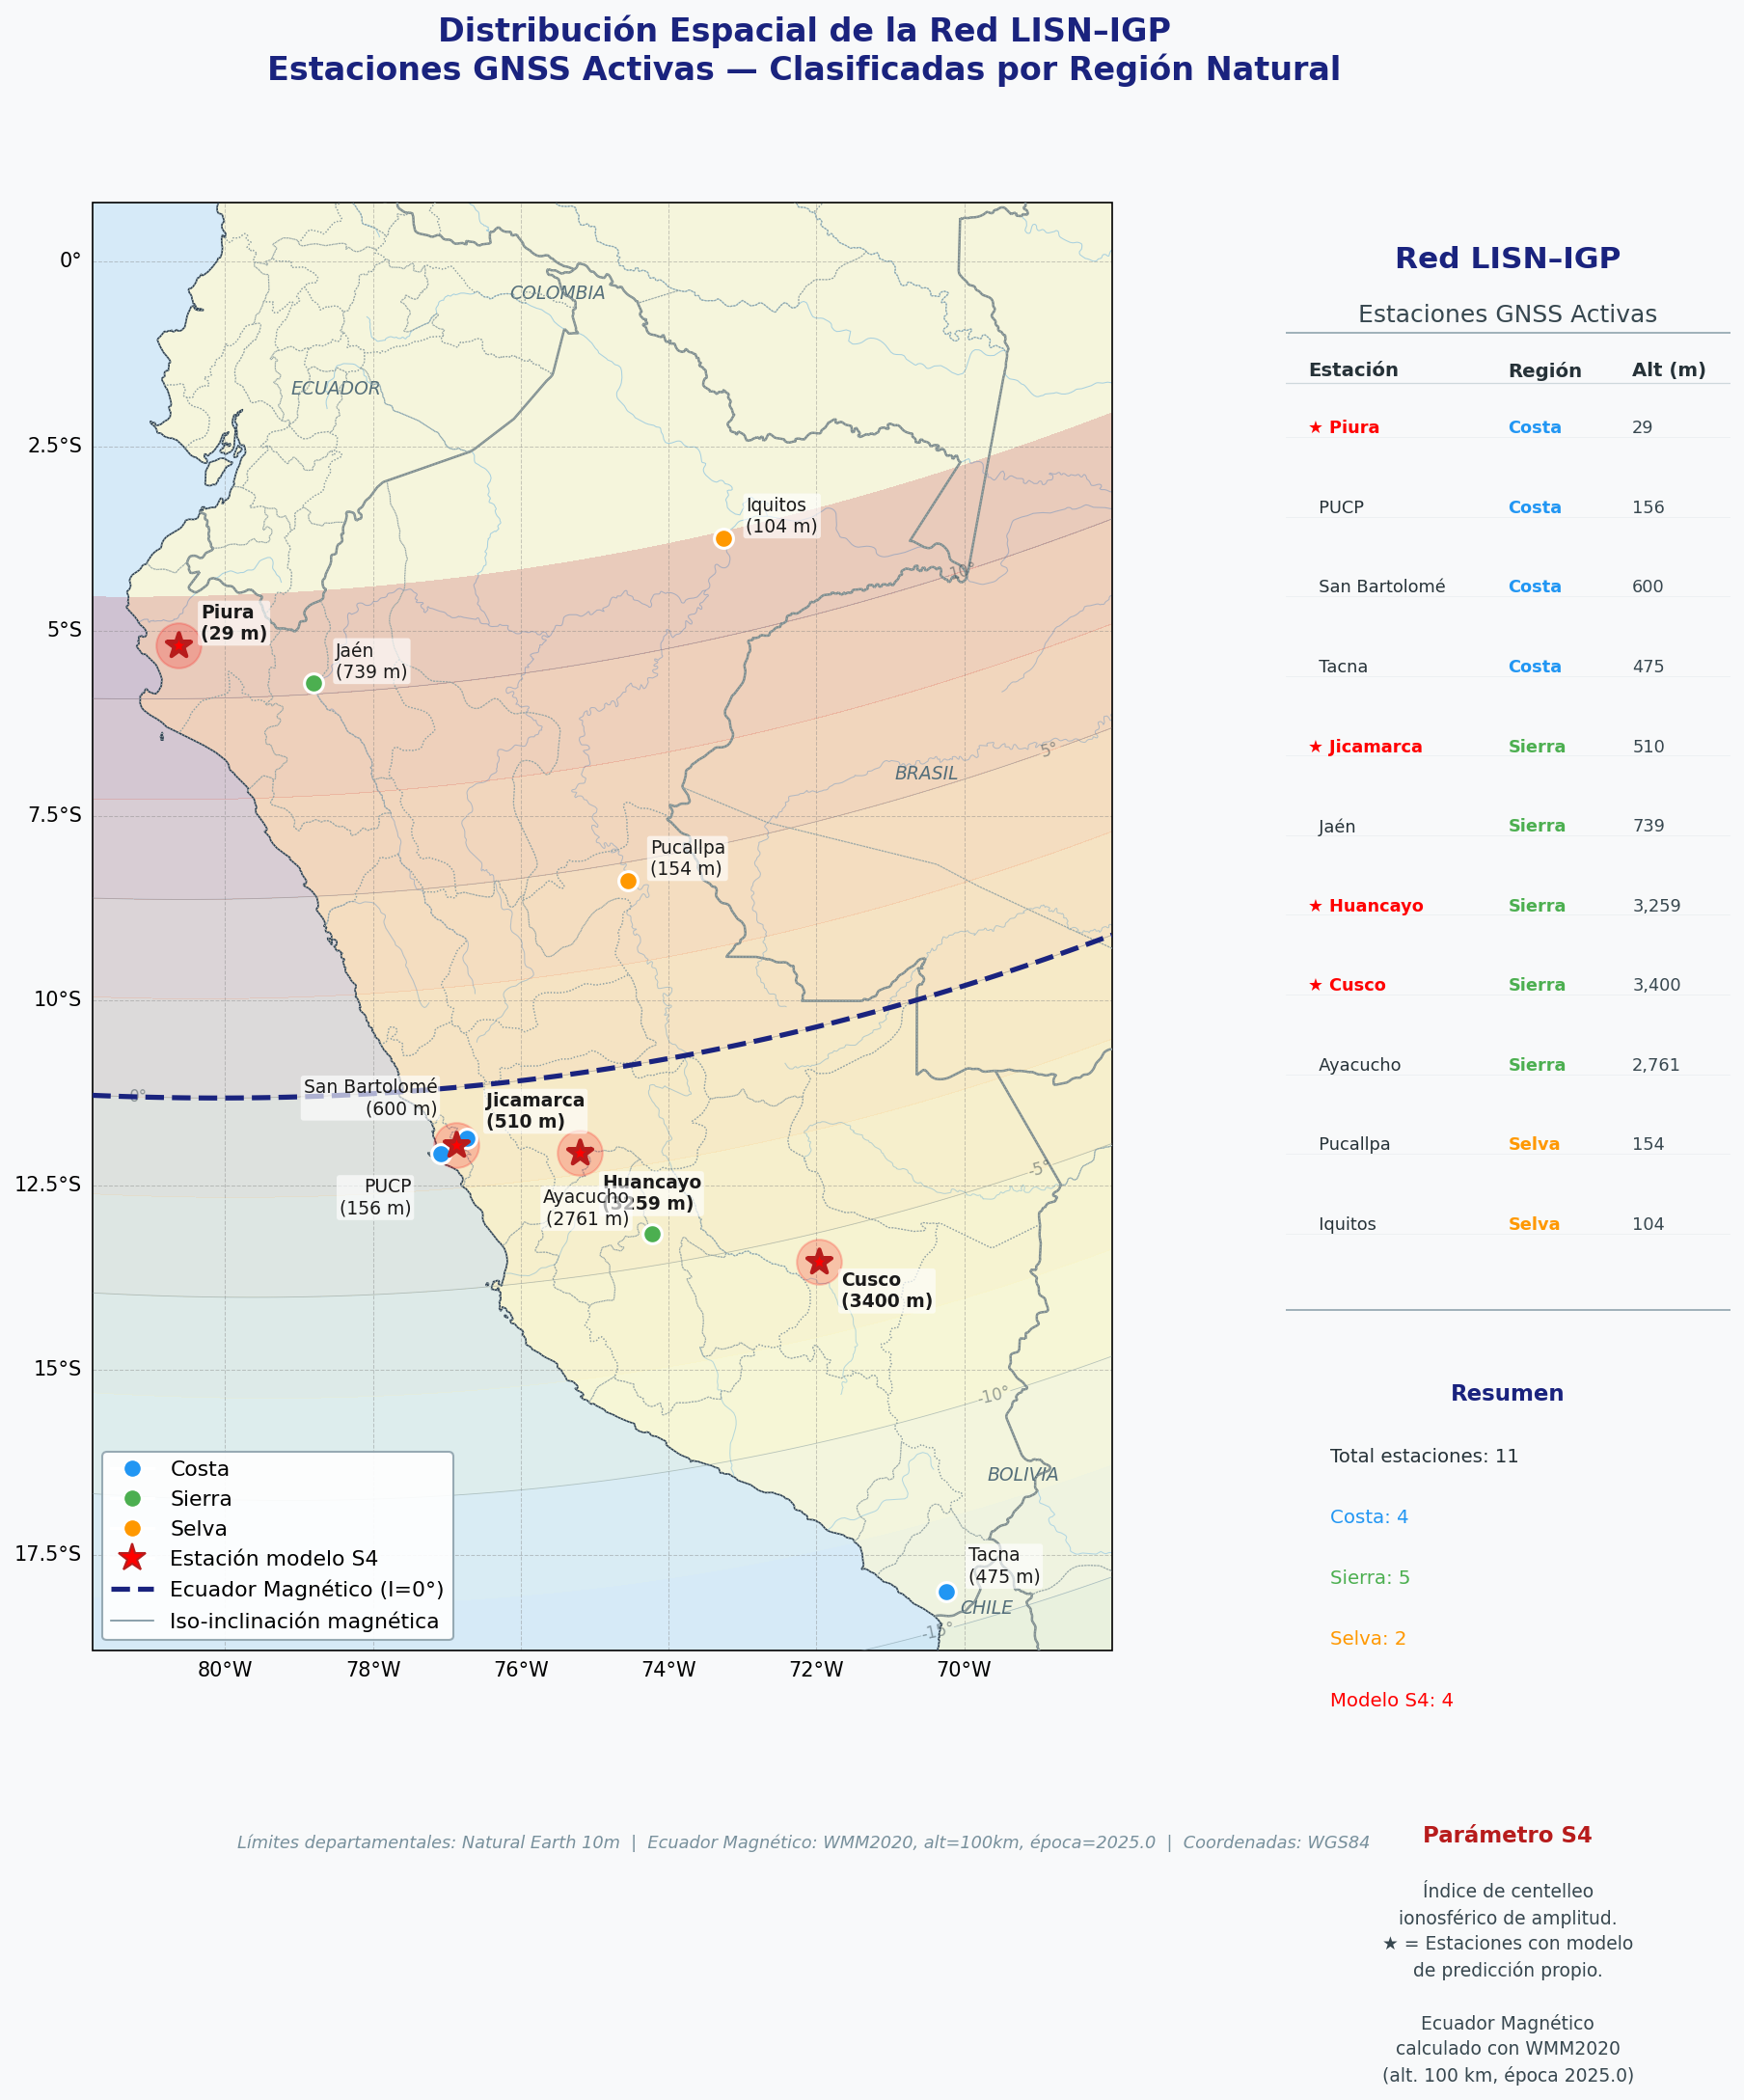

In [1]:
# ============================================================
# MAPA MEJORADO - LISN IGP + MODELO S4
# Con límites departamentales, mejor diferenciación y más info
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from wmm2020 import wmm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------
# 1. Grilla ajustada al Perú continental
# ------------------------------------------------------------
lons = np.linspace(-81.8, -68.0, 200)
lats = np.linspace(-18.8, 0.8, 200)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# ------------------------------------------------------------
# 2. Calcular inclinación magnética
# ------------------------------------------------------------
inclination = np.zeros_like(lat_grid)
for i in range(lat_grid.shape[0]):
    for j in range(lat_grid.shape[1]):
        B = wmm(lat_grid[i, j], lon_grid[i, j], 0.100, 2025.0)
        inclination[i, j] = B['incl']

# ------------------------------------------------------------
# 3. Estaciones con clasificación regional y altitud aprox.
# ------------------------------------------------------------
# (nombre): (lat, lon, región, altitud_m, nombre_display)
estaciones = {
    "PIURA":         (-5.1945,  -80.6328, "Costa",  29,    "Piura"),
    "PUCP":          (-12.0682, -77.0803, "Costa",  156,   "PUCP"),
    "SAN_BARTOLOME": (-11.8714, -76.7295, "Costa",  600,   "San Bartolomé"),
    "TACNA":         (-18.0066, -70.2463, "Costa",  475,   "Tacna"),
    "JICAMARCA":     (-11.9500, -76.8700, "Sierra", 510,   "Jicamarca"),
    "JAEN":          (-5.7082,  -78.8024, "Sierra", 739,   "Jaén"),
    "HUANCAYO":      (-12.0650, -75.2049, "Sierra", 3259,  "Huancayo"),
    "CUZCO":         (-13.5320, -71.9675, "Sierra", 3400,  "Cusco"),
    "AYACUCHO":      (-13.1631, -74.2236, "Sierra", 2761,  "Ayacucho"),
    "PUCALLPA":      (-8.3791,  -74.5539, "Selva",  154,   "Pucallpa"),
    "IQUITOS":       (-3.7437,  -73.2516, "Selva",  104,   "Iquitos"),
}

# Estaciones usadas en el modelo S4
estaciones_modelo = {"PIURA", "JICAMARCA", "HUANCAYO", "CUZCO"}

# Colores por región
colores_region = {
    "Costa": "#2196F3",   # Azul
    "Sierra": "#4CAF50",  # Verde
    "Selva":  "#FF9800",  # Naranja
}

# ------------------------------------------------------------
# 4. Figura principal con panel lateral de información
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 13), dpi=150, facecolor='#F8F9FA')

gs = GridSpec(1, 2, figure=fig, width_ratios=[3, 1], wspace=0.02)

ax = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax_info = fig.add_subplot(gs[1])
ax_info.axis('off')

ax.set_extent([-81.8, -68.0, -18.8, 0.8])
ax.set_facecolor('#D6EAF8')  # Fondo oceánico

# ------------------------------------------------------------
# 5. Capas geográficas
# ------------------------------------------------------------
# Tierra con gradiente visual
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    facecolor='#F5F5DC', edgecolor='none'
)
ax.add_feature(land, zorder=1)

# Ríos
ax.add_feature(cfeature.RIVERS.with_scale('10m'),
               linewidth=0.5, alpha=0.5, edgecolor='#5DADE2', zorder=2)

# Línea costera
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.8, edgecolor='#2C3E50', zorder=3)

# Fronteras internacionales
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linestyle='-', linewidth=1.2,
               edgecolor='#7F8C8D', zorder=3)

# Límites departamentales (admin_1)
try:
    states_shp = shpreader.natural_earth(
        resolution='10m',
        category='cultural',
        name='admin_1_states_provinces'
    )
    states = cfeature.ShapelyFeature(
        [geom for geom in shpreader.Reader(states_shp).geometries()],
        ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='#95A5A6',
        linewidth=0.6,
        linestyle=':'
    )
    ax.add_feature(states, zorder=4)
    print("✓ Límites departamentales cargados")
except Exception as e:
    print(f"Advertencia límites departamentales: {e}")

# ------------------------------------------------------------
# 6. Fondo de inclinación magnética (contornos de fondo)
# ------------------------------------------------------------
cf = ax.contourf(lon_grid, lat_grid, inclination,
                 levels=np.arange(-30, 15, 2.5),
                 cmap='RdYlBu_r',
                 alpha=0.18,
                 zorder=2,
                 transform=ccrs.PlateCarree())

# Contornos de inclinación magnética (líneas)
cs = ax.contour(lon_grid, lat_grid, inclination,
                levels=np.arange(-25, 15, 5),
                colors='#78909C',
                linewidths=0.4,
                alpha=0.5,
                linestyles='-',
                zorder=3,
                transform=ccrs.PlateCarree())
ax.clabel(cs, fmt='%d°', fontsize=8, inline=True, colors='#37474F')

# Ecuador Magnético (línea principal)
ax.contour(lon_grid, lat_grid, inclination,
           levels=[0],
           colors='#1A237E',
           linewidths=2.5,
           linestyles='--',
           zorder=5,
           transform=ccrs.PlateCarree())

# ------------------------------------------------------------
# 7. Dibujar estaciones
# ------------------------------------------------------------
offsets = {
    "PIURA":         (0.3,   0.3,  'left'),
    "PUCP":          (-0.4, -0.6,  'right'),
    "SAN_BARTOLOME": (-0.4,  0.55, 'right'),
    "JICAMARCA":     (0.4,   0.45, 'left'),
    "TACNA":         (0.3,   0.35, 'left'),
    "HUANCAYO":      (0.3,  -0.55, 'left'),
    "CUZCO":         (0.3,  -0.4,  'left'),
    "AYACUCHO":      (-0.3,  0.35, 'right'),
    "JAEN":          (0.3,   0.3,  'left'),
    "PUCALLPA":      (0.3,   0.3,  'left'),
    "IQUITOS":       (0.3,   0.3,  'left'),
}

for nombre, (lat, lon, region, alt, display) in estaciones.items():
    color = colores_region[region]
    es_modelo = nombre in estaciones_modelo

    # Halo / sombra para estaciones del modelo
    if es_modelo:
        ax.scatter(lon, lat,
                   s=500, color='red', alpha=0.2,
                   zorder=5, transform=ccrs.PlateCarree())
        ax.scatter(lon, lat,
                   s=160, color='red',
                   edgecolor='#B71C1C', linewidth=2,
                   marker='*', zorder=7,
                   transform=ccrs.PlateCarree())
    else:
        ax.scatter(lon, lat,
                   s=90, color=color,
                   edgecolor='white', linewidth=1.5,
                   marker='o', zorder=6,
                   transform=ccrs.PlateCarree())

    dx, dy, ha = offsets.get(nombre, (0.3, 0.3, 'left'))

    # Texto con sombra (fondo blanco semitransparente)
    txt = ax.text(lon + dx, lat + dy,
                  f"{display}\n({alt} m)",
                  fontsize=9,
                  weight='bold' if es_modelo else 'normal',
                  ha=ha, va='center',
                  color='#1A1A1A',
                  zorder=8,
                  transform=ccrs.PlateCarree())
    txt.set_bbox(dict(facecolor='white', alpha=0.65,
                      edgecolor='none', boxstyle='round,pad=0.15'))

# ------------------------------------------------------------
# 8. Etiquetas de países vecinos
# ------------------------------------------------------------
vecinos = {
    "COLOMBIA": (-0.5, -75.5),
    "ECUADOR":  (-1.8, -78.5),
    "BRASIL":   (-7.0, -70.5),
    "BOLIVIA":  (-16.5, -69.2),
    "CHILE":    (-18.3, -69.7),
}
for pais, (plat, plon) in vecinos.items():
    if -81.8 < plon < -68.0 and -18.8 < plat < 0.8:
        ax.text(plon, plat, pais,
                fontsize=9, color='#546E7A',
                style='italic', ha='center',
                transform=ccrs.PlateCarree(), zorder=3)

# ------------------------------------------------------------
# 9. Graticule (meridianos y paralelos)
# ------------------------------------------------------------
gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                  color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# ------------------------------------------------------------
# 10. Leyenda principal
# ------------------------------------------------------------
legend_elements = [
    # --- Regiones ---
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colores_region["Costa"],
           markeredgecolor='white', markersize=9,
           label='Costa'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colores_region["Sierra"],
           markeredgecolor='white', markersize=9,
           label='Sierra'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colores_region["Selva"],
           markeredgecolor='white', markersize=9,
           label='Selva'),

    # --- Modelo S4 ---
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='red', markeredgecolor='#B71C1C',
           markersize=14, label='Estación modelo S4'),

    # --- Ecuador Magnético ---
    Line2D([0], [0], color='#1A237E', lw=2.5,
           linestyle='--', label='Ecuador Magnético (I=0°)'),

    # --- Contornos inclinación ---
    Line2D([0], [0], color='#78909C', lw=0.8,
           linestyle='-', label='Iso-inclinación magnética'),
]

leg = ax.legend(handles=legend_elements,
                loc='lower left',
                fontsize=10.5,
                framealpha=0.92,
                edgecolor='#90A4AE',
                fancybox=True)

# ------------------------------------------------------------
# 11. Panel lateral de información
# ------------------------------------------------------------
ax_info.set_xlim(0, 1)
ax_info.set_ylim(0, 1)

# Título del panel
ax_info.text(0.5, 0.97, "Red LISN–IGP",
             ha='center', va='top', fontsize=15,
             weight='bold', color='#1A237E')
ax_info.text(0.5, 0.93, "Estaciones GNSS Activas",
             ha='center', va='top', fontsize=12, color='#37474F')

ax_info.axhline(0.91, color='#90A4AE', linewidth=0.8)

# Tabla de estaciones
headers = ["Estación", "Región", "Alt (m)"]
col_x = [0.05, 0.5, 0.78]
y_start = 0.89

ax_info.text(col_x[0], y_start, headers[0], fontsize=9.5,
             weight='bold', va='top', color='#263238')
ax_info.text(col_x[1], y_start, headers[1], fontsize=9.5,
             weight='bold', va='top', color='#263238')
ax_info.text(col_x[2], y_start, headers[2], fontsize=9.5,
             weight='bold', va='top', color='#263238')

ax_info.axhline(y_start - 0.015, color='#CFD8DC', linewidth=0.6)

y = y_start - 0.04
for nombre, (lat, lon, region, alt, display) in estaciones.items():
    es_modelo = nombre in estaciones_modelo
    color_txt = 'red' if es_modelo else '#263238'
    weight_txt = 'bold' if es_modelo else 'normal'

    marker = "★ " if es_modelo else "  "

    ax_info.text(col_x[0], y, f"{marker}{display}",
                 fontsize=8.5, va='top',
                 color=color_txt, weight=weight_txt)
    ax_info.text(col_x[1], y, region,
                 fontsize=8.5, va='top',
                 color=colores_region[region], weight='bold')
    ax_info.text(col_x[2], y, f"{alt:,}",
                 fontsize=8.5, va='top', color='#37474F')

    ax_info.axhline(y - 0.012, color='#ECEFF1', linewidth=0.4)
    y -= 0.055

# Resumen estadístico
ax_info.axhline(y - 0.01, color='#90A4AE', linewidth=0.8)
y -= 0.06

n_total = len(estaciones)
n_costa  = sum(1 for v in estaciones.values() if v[2] == "Costa")
n_sierra = sum(1 for v in estaciones.values() if v[2] == "Sierra")
n_selva  = sum(1 for v in estaciones.values() if v[2] == "Selva")

ax_info.text(0.5, y, "Resumen", ha='center', fontsize=11,
             weight='bold', va='top', color='#1A237E')
y -= 0.045
resumen = [
    (f"Total estaciones: {n_total}", '#263238'),
    (f"Costa: {n_costa}",           colores_region["Costa"]),
    (f"Sierra: {n_sierra}",         colores_region["Sierra"]),
    (f"Selva: {n_selva}",           colores_region["Selva"]),
    (f"Modelo S4: {len(estaciones_modelo)}", 'red'),
]
for txt, col in resumen:
    ax_info.text(0.1, y, txt, fontsize=9.5, va='top', color=col)
    y -= 0.042

# Nota del modelo
ax_info.axhline(y - 0.005, color='#90A4AE', linewidth=0.8)
y -= 0.05
ax_info.text(0.5, y, "Parámetro S4", ha='center',
             fontsize=11, weight='bold', va='top', color='#B71C1C')
y -= 0.04
nota = ("Índice de centelleo\nionosférico de amplitud.\n"
        "★ = Estaciones con modelo\nde predicción propio.\n\n"
        "Ecuador Magnético\ncalculado con WMM2020\n(alt. 100 km, época 2025.0)")
ax_info.text(0.5, y, nota, ha='center', fontsize=9,
             va='top', color='#37474F',
             linespacing=1.5)

# Borde del panel
for spine in ax_info.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# 12. Título principal
# ------------------------------------------------------------
fig.suptitle(
    "Distribución Espacial de la Red LISN–IGP\n"
    "Estaciones GNSS Activas — Clasificadas por Región Natural",
    fontsize=16, weight='bold', color='#1A237E', y=0.98
)

# Nota de datos
fig.text(0.5, 0.005,
         "Límites departamentales: Natural Earth 10m  |  "
         "Ecuador Magnético: WMM2020, alt=100km, época=2025.0  |  "
         "Coordenadas: WGS84",
         ha='center', fontsize=8.5, color='#78909C', style='italic')

plt.savefig("/mnt/user-data/outputs/Mapa_LISN_IGP_Mejorado.png",
            dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

print("✓ Mapa guardado exitosamente")
plt.show()